# POC: Same-donor, cross-protocol replicates in SEA-AD (no model training)

**Question:** Do open SEA-AD data contain donors measured with *two* RNA protocols (10x singleome vs. 10x multiome),
and is a donor's cell-type profile more similar to *itself in the other protocol* than to *other donors*?

**Steps**
1. Find SEA-AD datasets in the CELLxGENE Census and count donors measured with both assays (metadata only).
2. Fetch counts for one cell type (default: astrocytes) for those donors, subsampled.
3. Pseudobulk per (donor, assay) → similarity analysis + donor retrieval across protocols.
4. Gene-level: which genes shift *consistently* between protocols within donors (gene-specific technical bias).

Requirements: `pip install cellxgene-census scanpy pandas numpy scipy matplotlib seaborn`
(Census needs internet; metadata queries take ~1–3 min, expression fetch longer.)


In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
import cellxgene_census

CENSUS_VERSION = "stable"  
CELL_TYPE_KEYWORD = "astrocyte"   # we can try also "microglial" or "oligodendrocyte"
TISSUE_KEYWORD = "temporal"       # SEA-AD middle temporal gyrus (MTG); set to None to ignore tissue
MAX_CELLS_PER_GROUP = 100         # per (donor, assay) - keeps memory small
MIN_CELLS_PER_GROUP = 50          # drop pseudobulks built from too few cells
SEED = 0

census = cellxgene_census.open_soma(census_version=CENSUS_VERSION)
print(census["census_info"]["summary"].read().concat().to_pandas())

The "stable" release is currently 2025-11-08. Specify 'census_version="2025-11-08"' in future calls to open_soma() to ensure data consistency.


   soma_joinid                   label       value
0            0   census_schema_version       2.4.0
1            1       census_build_date  2025-11-08
2            2  dataset_schema_version       7.0.0
3            3        total_cell_count   217768036
4            4       unique_cell_count   125463259


## 1. Find SEA-AD datasets and matched donors (metadata only)

In [2]:
datasets = census["census_info"]["datasets"].read().concat().to_pandas()
sea = datasets[datasets["collection_name"].str.contains("SEA-AD|Seattle Alzheimer", case=False, na=False)]
print(f"{len(sea)} SEA-AD datasets in Census")
sea[["dataset_id", "dataset_title", "dataset_total_cell_count"]]

50 SEA-AD datasets in Census


,dataset_id,dataset_title,dataset_total_cell_count
298,3e87b1fa-472a-401c-8fa8-f31c10437d5f,Endothelial - MTG: Seattle Alzheimer's Disease...,2069
363,81e91ff8-f619-4ad1-a0c3-b45e1dc63f68,Sst Chodl - MTG: Seattle Alzheimer's Disease A...,1496
410,2ecc72f8-085f-4e86-8692-771f316c54f6,Endothelial - DLPFC: Seattle Alzheimer's Disea...,2575
453,236baeda-5fdd-41bf-8e32-bae21ac7d435,VLMC - MTG: Seattle Alzheimer's Disease Atlas ...,4328
518,fc0ceb80-d2d9-47c1-9d78-b0e45c64c500,Sst Chodl - DLPFC: Seattle Alzheimer's Disease...,1877
560,2e5a9b5d-d31b-4e9f-a179-d5d70ba459fb,VLMC - DLPFC: Seattle Alzheimer's Disease Atla...,4860
617,07428d73-fdea-4bd4-a801-94b00c4d961c,L5 ET - MTG: Seattle Alzheimer's Disease Atlas...,2590
908,8c6ed88f-11bf-4159-bad7-ff41fb1e1eca,Chandelier - MTG: Seattle Alzheimer's Disease ...,10928
910,f67f2cfa-ba45-4f77-8e26-64a15f666043,Pax6 - MTG: Seattle Alzheimer's Disease Atlas ...,9203
943,6cda07c7-5d7a-41ba-9799-5bb73da25a60,L5 ET - DLPFC: Seattle Alzheimer's Disease Atl...,4097


In [3]:
obs_cols = ["soma_joinid", "dataset_id", "donor_id", "assay", "cell_type", "tissue",
            "disease", "sex", "development_stage", "is_primary_data"]
ids = "', '".join(sea["dataset_id"])
obs = (census["census_data"]["homo_sapiens"].obs
       .read(value_filter=f"dataset_id in ['{ids}']", column_names=obs_cols)
       .concat().to_pandas())
print(obs.shape)
print(obs.groupby(["assay", "is_primary_data"], observed=True).size())
print(obs["tissue"].value_counts().head(15))

(5547624, 10)
assay         is_primary_data
10x 3' v3     False              2613373
              True               2459165
10x multiome  False               237543
              True                237543
dtype: int64
tissue
dorsolateral prefrontal cortex    2791202
middle temporal gyrus             2756422
parenchyma of mammary gland             0
peritoneum                              0
perirenal fat                           0
peripheral zone of prostate             0
peripheral region of retina             0
periodontium                            0
perifoveal part of retina               0
parotid gland                           0
parietal peritoneum                     0
parietal lobe                           0
parietal cortex                         0
Brodmann (1909) area 10                 0
pigment epithelium of eye               0
Name: count, dtype: int64


Cells appear in several datasets of the collection (whole atlas plus cell-type subsets); is_primary_data confirms duplication (e.g., each multiome nucleus appears twice). We therefore use one dataset per assay for analysis (see step 2).

In [4]:
sub = obs.copy()
if TISSUE_KEYWORD:
    sub = sub[sub["tissue"].str.contains(TISSUE_KEYWORD, case=False, na=False)]
print("Assays:", sub["assay"].value_counts().to_dict())

# donors x assays: how many cells each donor has per assay
donor_assay = sub.groupby(["donor_id", "assay"], observed=True).size().unstack(fill_value=0)
display(donor_assay.head())

assays = donor_assay.columns.tolist()
both = donor_assay[(donor_assay > 0).sum(axis=1) >= 2]
print(f"\nDonors total: {len(donor_assay)}  |  donors with >=2 assays: {len(both)}")
print("RESULT 1 -> number of matched cross-protocol donors:", len(both))

Assays: {"10x 3' v3": 2453710, '10x multiome': 302712, "10x 3' transcription profiling": 0, 'Smart-seq2': 0, 'STRT-seq': 0, 'ScaleBio single cell RNA sequencing': 0, 'Seq-Well': 0, 'Seq-Well S3': 0, 'Smart-seq': 0, 'Smart-seq v4': 0, 'TruDrop': 0, 'Smart-seq3': 0, 'SORT-seq': 0, 'inDrop': 0, 'mCT-seq': 0, 'microwell-seq': 0, 'modified STRT-seq': 0, 'particle-templated instant partition sequencing': 0, 'SPLiT-seq': 0, 'Parse Evercode Whole Transcriptome v2': 0, 'Quartz-seq': 0, 'BD Rhapsody Targeted mRNA': 0, "10x 3' v2": 0, "10x 5' transcription profiling": 0, "10x 5' v1": 0, "10x 5' v2": 0, '10x gene expression flex': 0, 'Asteria scRNA-seq kit': 0, 'BD Rhapsody Whole Transcriptome Analysis': 0, "10x 3' v1": 0, 'CEL-seq': 0, 'CEL-seq2': 0, 'Drop-seq': 0, 'GEXSCOPE technology': 0, 'HIVE CLX Single-Cell RNAseq Solution': 0, 'MARS-seq': 0, 'sci-RNA-seq3': 0}


assay,10x 3' v3,10x multiome
donor_id,,
H18.30.001,38586,0
H18.30.002,62358,0
H19.30.001,99816,0
H19.30.002,60888,0
H19.33.004,57878,0



Donors total: 89  |  donors with >=2 assays: 28
RESULT 1 -> number of matched cross-protocol donors: 28


So there are only 2 assays in this dataset: "10x 3' v3" and "10x multiome". Number of samples are 2,453,710 and 302,712 respectively (there are more multiome samples).


In [5]:
display(donor_assay[donor_assay["10x multiome"] > 0].head())

assay,10x 3' v3,10x multiome
donor_id,,
H20.33.001,30326,9636
H20.33.002,29468,11890
H20.33.004,29074,13182
H20.33.005,41976,13248
H20.33.008,3996,16828


In [6]:
sub.groupby(["donor_id", "assay"], observed=True).size().unstack(fill_value=0)

assay,10x 3' v3,10x multiome
donor_id,,
H18.30.001,38586,0
H18.30.002,62358,0
H19.30.001,99816,0
H19.30.002,60888,0
H19.33.004,57878,0
...,...,...
H21.33.043,30010,0
H21.33.044,12538,0
H21.33.045,13678,0


## 2. Fetch counts for one cell type in matched donors (subsampled)

In [ ]:
ct_counts = sub[sub["donor_id"].isin(both.index)]["cell_type"].value_counts()
print(ct_counts.head(20))

# we choose astrocytes cell types and the donors with both assays
ct_mask = sub["cell_type"].str.contains(CELL_TYPE_KEYWORD, case=False, na=False)
sel = sub[ct_mask & sub["donor_id"].isin(both.index)]

# if a cell appears in several datasets, keep one dataset per assay (the largest one)
main_ds = sel.groupby(["assay", "dataset_id"]).size().reset_index(name="n") \
             .sort_values("n", ascending=False).drop_duplicates("assay")
print(main_ds)
# keeps only cells whose assay and dataset match a kept pair, so the duplicate copies from the other dataset are dropped
sel = sel.merge(main_ds[["assay", "dataset_id"]], on=["assay", "dataset_id"])

# subsample per donor x assay
sel = (sel.groupby(["donor_id", "assay"], group_keys=False)
          .apply(lambda g: g.sample(min(len(g), MAX_CELLS_PER_GROUP), random_state=SEED)))
print(f"Cells to fetch: {len(sel)}  ({sel['cell_type'].unique()})")

cell_type
L2/3-6 intratelencephalic projecting glutamatergic neuron         549420
oligodendrocyte                                                    80554
VIP GABAergic cortical interneuron                                 74758
pvalb GABAergic cortical interneuron                               64536
astrocyte of the cerebral cortex                                   56796
lamp5 GABAergic cortical interneuron                               46990
sst GABAergic cortical interneuron                                 37404
microglial cell                                                    30520
oligodendrocyte precursor cell                                     23720
sncg GABAergic cortical interneuron                                16152
near-projecting glutamatergic cortical neuron                      14966
corticothalamic-projecting glutamatergic cortical neuron           14614
L6b glutamatergic cortical neuron                                  12822
chandelier pvalb GABAergic cortical inter

/var/folders/6b/mxnfm2d5597g920s2q_dzv_r0000gn/T/ipykernel_21997/3007373839.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  main_ds = sel.groupby(["assay", "dataset_id"]).size().reset_index(name="n") \
/var/folders/6b/mxnfm2d5597g920s2q_dzv_r0000gn/T/ipykernel_21997/3007373839.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sel = (sel.groupby(["donor_id", "assay"], group_keys=False)
/var/folders/6b/mxnfm2d5597g920s2q_dzv_r0000gn/T/ipykernel_21997/3007373839.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the

In [ ]:
# display one group
display(next(iter(sel.groupby(["donor_id", "assay"], group_keys=False))))

/var/folders/6b/mxnfm2d5597g920s2q_dzv_r0000gn/T/ipykernel_21997/781974414.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(next(iter(sel.groupby(["donor_id", "assay"], group_keys=False))))


(('H20.33.001', "10x 3' v3"),
        soma_joinid                            dataset_id    donor_id  \
 24374    157393798  c2876b1b-06d8-4d96-a56b-5304f815b99a  H20.33.001   
 20279    157193157  c2876b1b-06d8-4d96-a56b-5304f815b99a  H20.33.001   
 14484    156911765  c2876b1b-06d8-4d96-a56b-5304f815b99a  H20.33.001   
 13328    156854501  c2876b1b-06d8-4d96-a56b-5304f815b99a  H20.33.001   
 10589    156723087  c2876b1b-06d8-4d96-a56b-5304f815b99a  H20.33.001   
 ...            ...                                   ...         ...   
 2742     156343803  c2876b1b-06d8-4d96-a56b-5304f815b99a  H20.33.001   
 21095    157232579  c2876b1b-06d8-4d96-a56b-5304f815b99a  H20.33.001   
 12120    156797193  c2876b1b-06d8-4d96-a56b-5304f815b99a  H20.33.001   
 6263     156509554  c2876b1b-06d8-4d96-a56b-5304f815b99a  H20.33.001   
 5382     156468197  c2876b1b-06d8-4d96-a56b-5304f815b99a  H20.33.001   
 
            assay                         cell_type                 tissue  \
 24374  10x 3'

In [18]:
pd.set_option("display.max_colwidth", 120)
print(sea[sea["dataset_id"] == "c2876b1b-06d8-4d96-a56b-5304f815b99a"][["dataset_id", "dataset_title", "dataset_total_cell_count"]])
print("--------------------------------")
print(sea[sea["dataset_title"].str.contains("astro", case=False)][["dataset_id", "dataset_title", "dataset_total_cell_count"]])

                                dataset_id  \
1843  c2876b1b-06d8-4d96-a56b-5304f815b99a   

                                                         dataset_title  \
1843  Whole Taxonomy - MTG: Seattle Alzheimer's Disease Atlas (SEA-AD)   

      dataset_total_cell_count  
1843                   1378211  
--------------------------------
                                dataset_id  \
1474  5097d77d-08fa-4105-a18f-4072d61522a4   
1595  74d584f0-74fc-482e-b944-e76f29c1ab85   

                                                      dataset_title  \
1474    Astrocyte - MTG: Seattle Alzheimer's Disease Atlas (SEA-AD)   
1595  Astrocyte - DLPFC: Seattle Alzheimer's Disease Atlas (SEA-AD)   

      dataset_total_cell_count  
1474                     70009  
1595                     87444  


In [20]:
DATASET_ID = "5097d77d-08fa-4105-a18f-4072d61522a4"

import anndata as ad
import os
if not os.path.exists("seaad_astro.h5ad"):
    cellxgene_census.download_source_h5ad(DATASET_ID, to_path="seaad_astro.h5ad",
                                          census_version=CENSUS_VERSION)
full = ad.read_h5ad("seaad_astro.h5ad")

In [22]:
import anndata as ad
full = ad.read_h5ad("seaad_astro.h5ad")
print(full)                       # check size, obs columns, whether .raw exists

counts = full.raw.to_adata() if full.raw is not None else full   # raw counts, we need them for pseudobulk calculation
counts.var_names = full.var["feature_name"].astype(str).values   # gene symbols instead of Ensembl IDs
counts.var_names_make_unique()


# keeps cells that are from the 28 matched donors (both), are astrocytes, and come from middle temporal gyrus (MTG).
m = (counts.obs["donor_id"].astype(str).isin(both.index.astype(str))
     & counts.obs["cell_type"].astype(str).str.contains(CELL_TYPE_KEYWORD, case=False)
     & counts.obs["tissue"].astype(str).str.contains("temporal", case=False))
adata = counts[m].copy()

# subsample per donor x assay, as before
if not os.path.exists("seaad_astro_matched.h5ad"):
    rng = np.random.default_rng(SEED)
    keep = (adata.obs.groupby(["donor_id", "assay"], observed=True).indices) # unique cells per donor x assay
    idx = np.concatenate([rng.choice(v, min(len(v), MAX_CELLS_PER_GROUP), replace=False) for v in keep.values()]) # randomly sample cells per donor x assay
    adata = adata[np.sort(idx)].copy()
    adata.write_h5ad("seaad_astro_matched.h5ad")
else:
    adata = ad.read_h5ad("seaad_astro_matched.h5ad")

print(adata)

AnnData object with n_obs × n_vars = 70009 × 35483
    obs: 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'is_primary_data', 'Neurotypical reference', 'Class', 'Subclass', 'Supertype', 'Age at death', 'Years of education', 'Cognitive status', 'ADNC', 'Braak stage', 'Thal phase', 'CERAD score', 'APOE4 status', 'Lewy body disease pathology', 'LATE-NC stage', 'Microinfarct pathology', 'Specimen ID', 'donor_id', 'PMI', 'Number of UMIs', 'Genes detected', 'Fraction mitochrondrial UMIs', 'suspension_type', 'development_stage_ontology_term_id', 'Continuous Pseudo-progression Score', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'ADNC_colors', 'APOE

## 3. Pseudobulk per (donor, assay) and the key similarity test

In [ ]:
grp = adata.obs["donor_id"].astype(str) + "|" + adata.obs["assay"].astype(str)
sizes = grp.value_counts()
keep_groups = sizes[sizes >= MIN_CELLS_PER_GROUP].index
# create a sparse matrix of the counts
X = adata.X.tocsr() if sp.issparse(adata.X) else sp.csr_matrix(adata.X)

# calculate pseudobulk per donor x assay
pb = {g: np.asarray(X[(grp == g).to_numpy()].sum(axis=0)).ravel() for g in keep_groups}
pb = pd.DataFrame(pb, index=adata.var_names).T          # rows: donor|assay, cols: genes
meta = pd.DataFrame([g.split("|") for g in pb.index], index=pb.index, columns=["donor", "assay"])

# keep only donors that still have both assays after the cell-count filter
ok = meta.groupby("donor")["assay"].nunique()
meta = meta[meta["donor"].isin(ok[ok >= 2].index)]
pb = pb.loc[meta.index]

# we count the total counts per donor x assay and normalize to CPM (devide pseudobulk gene counts by the total counts per donor x assay and multiply by 1e6)
cpm = pb.div(pb.sum(axis=1), axis=0) * 1e6
# how many of genes are expressed (above 10 CPM) in most of the donors
expressed = (cpm > 10).mean(axis=0) > 0.5 
logcpm = np.log1p(cpm.loc[:, expressed])
print(f"{meta['donor'].nunique()} donors x {meta['assay'].nunique()} assays, {logcpm.shape[1]} genes")

23 donors x 2 assays, 9451 genes


In [48]:
print(pb.shape)
pb.head(1)

(46, 35483)


,TSPAN6,TNMD,DPM1,SCYL3,FIRRM,FGR,CFH,FUCA2,GCLC,NFYA,...,ELOA3DP,ELOA3P,CDR1,ACTL10,PANO1,PRRC2B,UGT1A3,UGT1A5,F8A2,F8A1
H20.33.015|10x 3' v3,4.0,0.0,62.0,9.0,14.0,0.0,0.0,10.0,155.0,15.0,...,0.0,0.0,2.0,0.0,1.0,248.0,0.0,0.0,0.0,0.0


In [47]:
print(cpm.shape)
cpm.head(1)

(46, 35483)


,TSPAN6,TNMD,DPM1,SCYL3,FIRRM,FGR,CFH,FUCA2,GCLC,NFYA,...,ELOA3DP,ELOA3P,CDR1,ACTL10,PANO1,PRRC2B,UGT1A3,UGT1A5,F8A2,F8A1
H20.33.015|10x 3' v3,3.501198,0.0,54.268574,7.877697,12.254194,0.0,0.0,8.752996,135.671432,13.129494,...,0.0,0.0,1.750599,0.0,0.8753,217.074295,0.0,0.0,0.0,0.0


In [46]:
print(logcpm.shape)
logcpm.head(1)

(46, 9451)


,DPM1,SCYL3,FIRRM,GCLC,NFYA,STPG1,NIPAL3,LAS1L,ENPP4,ANKIB1,...,ENSG00000287720,ENSG00000287759,ENSG00000287862,ENSG00000287876,ENSG00000287893,ENSG00000287939,ENSG00000288025,ENSG00000288075,ENSG00000288088,PRRC2B
H20.33.015|10x 3' v3,4.012205,2.183542,2.584314,4.91758,2.648264,3.272746,3.305383,2.515993,2.44266,5.322741,...,1.963904,2.81872,4.864985,2.648264,1.963904,2.183542,3.091369,4.088411,2.765066,5.384836


In [49]:
print(logcpm.values.shape)

(46, 9451)


In [43]:
np.corrcoef(logcpm.values).shape


(46, 46)

In [56]:
idx = logcpm.index
a, b = meta.loc[idx[0]], meta.loc[idx[1]]
print(a.donor, a.assay, b.donor, b.assay)

H20.33.015 10x 3' v3 H21.33.019 10x multiome


                             count      mean       std       min       25%  \
pair type                                                                    
other donor, other protocol  506.0  0.861860  0.042229  0.664725  0.843860   
other donor, same protocol   506.0  0.880350  0.041915  0.689779  0.865747   
same donor, other protocol    23.0  0.927513  0.013312  0.902469  0.916393   

                                  50%       75%       max  
pair type                                                  
other donor, other protocol  0.871704  0.890657  0.924683  
other donor, same protocol   0.889396  0.908078  0.940343  
same donor, other protocol   0.926658  0.935947  0.950626  


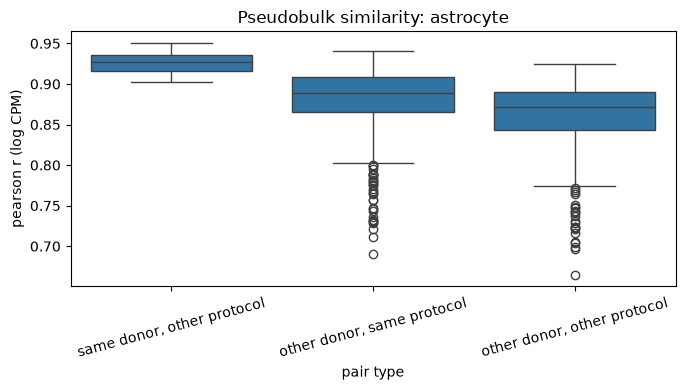

In [14]:
corr = np.corrcoef(logcpm.values)
corr = pd.DataFrame(corr, index=logcpm.index, columns=logcpm.index)

rows = []
idx = logcpm.index
for i in range(len(idx)):
    for j in range(i + 1, len(idx)):
        a, b = meta.loc[idx[i]], meta.loc[idx[j]]
        same_d, same_a = a.donor == b.donor, a.assay == b.assay
        cat = ("same donor, other protocol" if same_d and not same_a else
               "other donor, same protocol" if not same_d and same_a else
               "other donor, other protocol")
        rows.append((cat, corr.iloc[i, j]))
pairs = pd.DataFrame(rows, columns=["pair type", "pearson r (log CPM)"])
print(pairs.groupby("pair type")["pearson r (log CPM)"].describe())

order = ["same donor, other protocol", "other donor, same protocol", "other donor, other protocol"]
plt.figure(figsize=(7, 4))
sns.boxplot(data=pairs, x="pair type", y="pearson r (log CPM)", order=order)
plt.title(f"Pseudobulk similarity: {CELL_TYPE_KEYWORD}")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

In [19]:
census.close()